In [2]:
import pandas as pd

df = pd.read_csv("./data/DSI_kickstarterscrape_dataset.csv", encoding="latin-1")

print("Number of rows", len(df))
df.head()

Number of rows 45957


,project id,name,url,category,subcategory,location,status,goal,pledged,funded percentage,backers,funded date,levels,reward levels,updates,comments,duration
0,39409,WHILE THE TREES SLEEP,http://www.kickstarter.com/projects/emiliesaba...,Film & Video,Short Film,"Columbia, MO",successful,10500.0,11545.0,1.099524,66,"Fri, 19 Aug 2011 19:28:17 -0000",7,"$25,$50,$100,$250,$500,$1,000,$2,500",10,2,30.00
1,126581,Educational Online Trading Card Game,http://www.kickstarter.com/projects/972789543/...,Games,Board & Card Games,"Maplewood, NJ",failed,4000.0,20.0,0.005000,2,"Mon, 02 Aug 2010 03:59:00 -0000",5,"$1,$5,$10,$25,$50",6,0,47.18
2,138119,STRUM,http://www.kickstarter.com/projects/185476022/...,Film & Video,Animation,"Los Angeles, CA",live,20000.0,56.0,0.002800,3,"Fri, 08 Jun 2012 00:00:31 -0000",10,"$1,$10,$25,$40,$50,$100,$250,$1,000,$1,337,$9,001",1,0,28.00
3,237090,GETTING OVER - One son's search to finally kno...,http://www.kickstarter.com/projects/charnick/g...,Film & Video,Documentary,"Los Angeles, CA",successful,6000.0,6535.0,1.089167,100,"Sun, 08 Apr 2012 02:14:00 -0000",13,"$1,$10,$25,$30,$50,$75,$85,$100,$110,$250,$500...",4,0,32.22
4,246101,The Launch of FlyeGrlRoyalty &quot;The New Nam...,http://www.kickstarter.com/projects/flyegrlroy...,Fashion,Fashion,"Novi, MI",failed,3500.0,0.0,0.000000,0,"Wed, 01 Jun 2011 15:25:39 -0000",6,"$10,$25,$50,$100,$150,$250",2,0,30.00


In [3]:
# Is the ‘duration’ variable normally distributed?


duration_df = df.copy()




In [4]:
# Step 1: Remove any non-numeric 'duration' values

duration_df['duration'] = duration_df['duration'].apply(lambda x: x if isinstance(x, (int, float)) else None)

# Step 2: Drop any rows with missing values

duration_df = duration_df.dropna(subset=['duration'])

In [ ]:
# Step 3: Drop any duplicate rows

duration_df = duration_df.drop_duplicates(subset=["project id"])


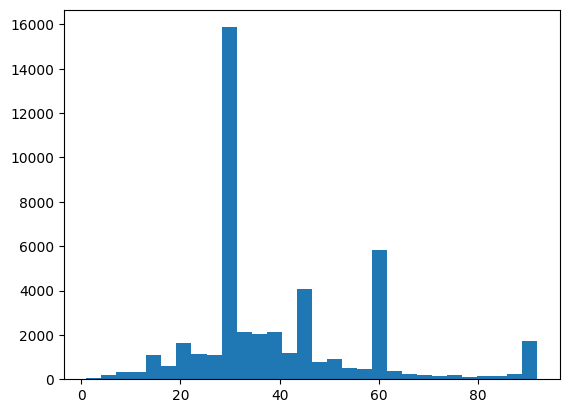

In [6]:
# Step 4: Plot the distribution of duration

import matplotlib.pyplot as plt

plt.hist(duration_df['duration'], bins=30)
plt.show()



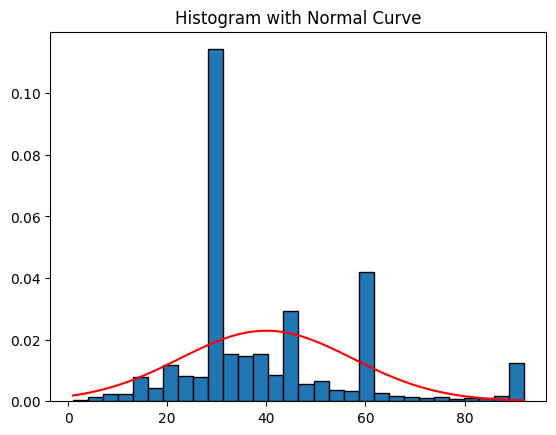

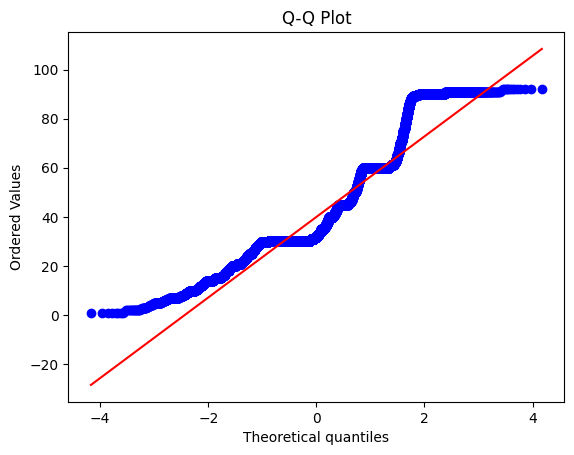

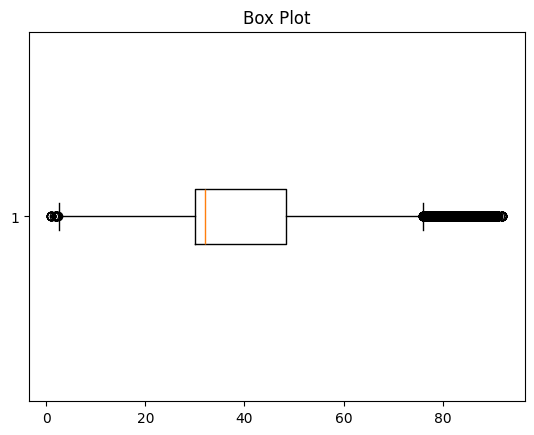

Skewness:           1.0785  (normal range: -0.5 to +0.5)
Kurtosis (excess):  1.0149  (normal range: -1 to +1)


In [ ]:
# Step 5: Determine if it is normally distributed

import numpy as np
import scipy.stats as stats

data = duration_df['duration']

# 1. Histogram with Normal Curve Overlay
# If the data is normal, the red curve should closely match the histogram shape.
plt.hist(data, bins=30, density=True, edgecolor='black')
x = np.linspace(data.min(), data.max(), 100)
plt.plot(x, stats.norm.pdf(x, data.mean(), data.std()), 'r')
plt.title('Histogram with Normal Curve')
plt.show()

# 2. Q-Q Plot
# Points falling along the diagonal line indicate normality.
# Deviations at the tails suggest skew or heavy tails.
stats.probplot(data, plot=plt)
plt.title('Q-Q Plot')
plt.show()


# 4. Skewness
# Skewness: normal range is -0.5 to +0.5; concern if |skew| > 1
skew = data.skew()
print(f"Skewness:           {skew:.4f}  (normal range: -0.5 to +0.5)")

# -----------------------------------------------------------------------
# Why we did NOT use statistical tests (Shapiro-Wilk, Kolmogorov-Smirnov):
#
# 1. Shapiro-Wilk is limited to n <= 5000 in most implementations.
#    Our dataset has ~45,000 rows, so it would error or require sampling.
#
# 2. Kolmogorov-Smirnov (and similar tests) are extremely sensitive at
#    large sample sizes -- even trivially small deviations from perfect
#    normality cause the test to reject, making it practically useless
#    for real-world data at this scale.
#
# 3. Visual methods (histogram, Q-Q plot, box plot) combined with
#    skewness give a more practical, interpretable
#    assessment of "how close to normal" the data is, rather than a
#    binary yes/no that is almost guaranteed to say "no" at n ~ 45k.
# -----------------------------------------------------------------------


## Is the Data Normally Distributed?

**No, the data is clearly not normally distributed.** Here's what each plot tells us:

---

### Histogram (Image 3)
- There is a **massive spike around 25–30**, making the distribution highly **right-skewed with a strong mode**
- A **second cluster appears around 55–65**, suggesting the data may be **bimodal**
- The red normal curve fits the data very poorly — the actual bars deviate dramatically from it
- There are also values clustered near **0 and near 90–95**, indicating possible boundary effects or distinct groups

---

### Q-Q Plot (Image 1)
- Points should follow the red diagonal line closely if the data were normal
- Instead, there is a **sharp staircase/step pattern**, especially around theoretical quantiles 1–2, indicating **discreteness or clustering**
- The **lower tail** (far left) shows points sitting flat near 0, meaning many values pile up there
- The **upper tail** flattens out around 90–95, showing a hard ceiling or truncation
- These S-shaped and step deviations are classic signs of **non-normality**

---


### Summary

| Evidence | Indicates |
|---|---|
| Spike at 25–30 in histogram | Non-normal, possible mode concentration |
| Bimodal shape | Two subgroups in the data |
| Step pattern in Q-Q plot | Discreteness / clustering |
| Long right whisker + outliers | Heavy right tail / skewness |

The data appears to be **multimodal, right-skewed, and possibly composed of distinct subgroups** — all of which violate the assumptions of normality.